In [380]:
# Import Libraries and Configure Matplotlib
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import re
import collections
from matplotlib import cm
from matplotlib import colors
from pycirclize import Circos
from tqdm import tqdm
import glob
import pandas as pd
import sys
import importlib
sys.path.append('../../')  # Adjust the path as needed

import utilities.functions as functions
import utilities.circ as circ
# Reload the module to reflect the changes
importlib.reload(functions)
importlib.reload(circ)

<module 'utilities.circ' from '/Users/xuechenkan/potts_model_test/utilities/circ.py'>

In [381]:
start_aa = 1  # Starting amino acid position
actual_length = 263
IN_path = '../../ms0.5/IN/'
PR_path = '../../ms0.5/PR/'
RT_path = '../../ms0.5/RT/'
IN_unreduced_seq_path = '/Users/xuechenkan/potts_model_test/ms1/IN/data/in.fullseq'

IN_kn_path = IN_path+'data/kn.her2.all'

IN_redux_dict = functions.get_redu_dict(IN_path+'data/in.reduce4.redux',1)
PR_redux_dict = functions.get_redu_dict(PR_path+'data/pr.reduce4.redux',0)
RT_redux_dict = functions.get_redu_dict(RT_path+'data/rt.reduce4.redux',0)

top_20_DRM = functions.read_list_from_file(IN_path + 'data/top_20_DRM.txt')
bottom_20_DRM = functions.read_list_from_file(IN_path + 'data/bottom_20_DRM.txt')
combined_DRM = top_20_DRM + bottom_20_DRM

Processing background chords: 100%|██████████| 50/50 [00:00<00:00, 6015.41it/s]


max_dde: 8.50879


Processing background chords: 100%|██████████| 19/19 [00:00<00:00, 3549.90it/s]


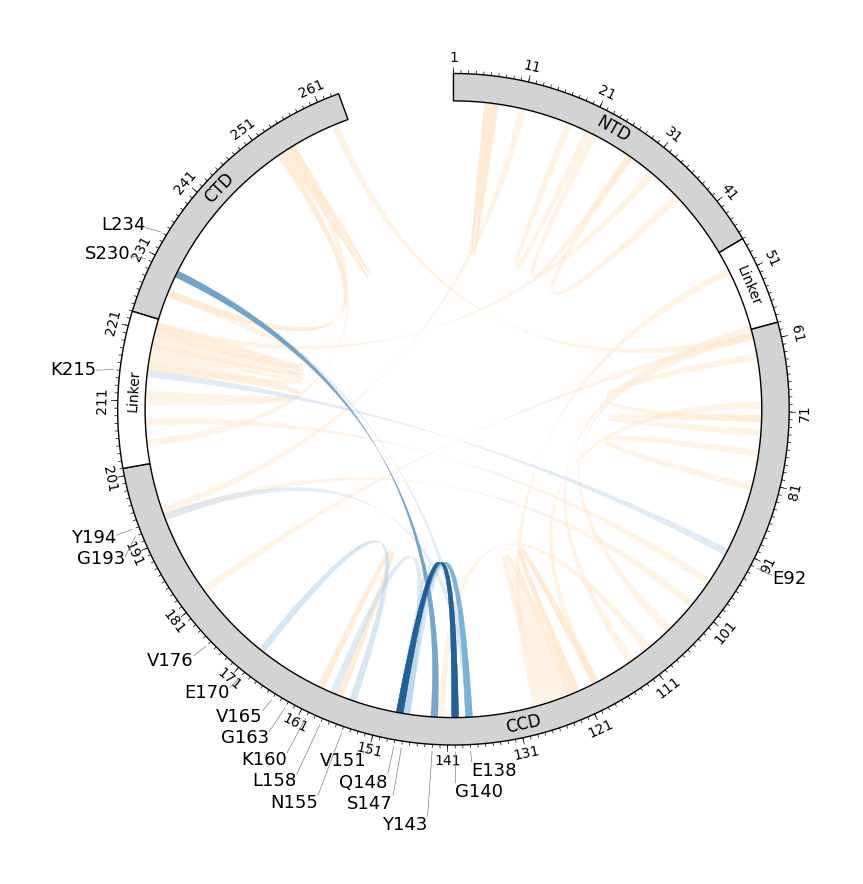

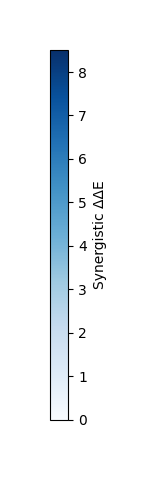

In [382]:
IN_circos_syn,sector =circ.initialize_IN_circos_w_ticks(actual_length, (90, 98))
circ.add_DRM_annotation(IN_circos_syn,sector, (100, 100),combined_DRM)
circ.connect_background_syn_cords(IN_circos_syn,sector,IN_kn_path, 50,1,0.5)
circ.connect_syn_cords(IN_circos_syn,sector,IN_kn_path, top_20_DRM,IN_redux_dict,1,0.5)
fig = IN_circos_syn.plotfig()


plt.show()
sm = circ.plot_colorbar(0, 8.50879, True)
cbar = plt.colorbar(sm, ax=plt.gca(), orientation='vertical', label='Synergistic ΔΔE')
plt.gca().remove()

Processing background chords: 100%|██████████| 50/50 [00:00<00:00, 7126.63it/s]


max_dde: -3.18745


Processing background chords: 100%|██████████| 18/18 [00:00<00:00, 3024.13it/s]


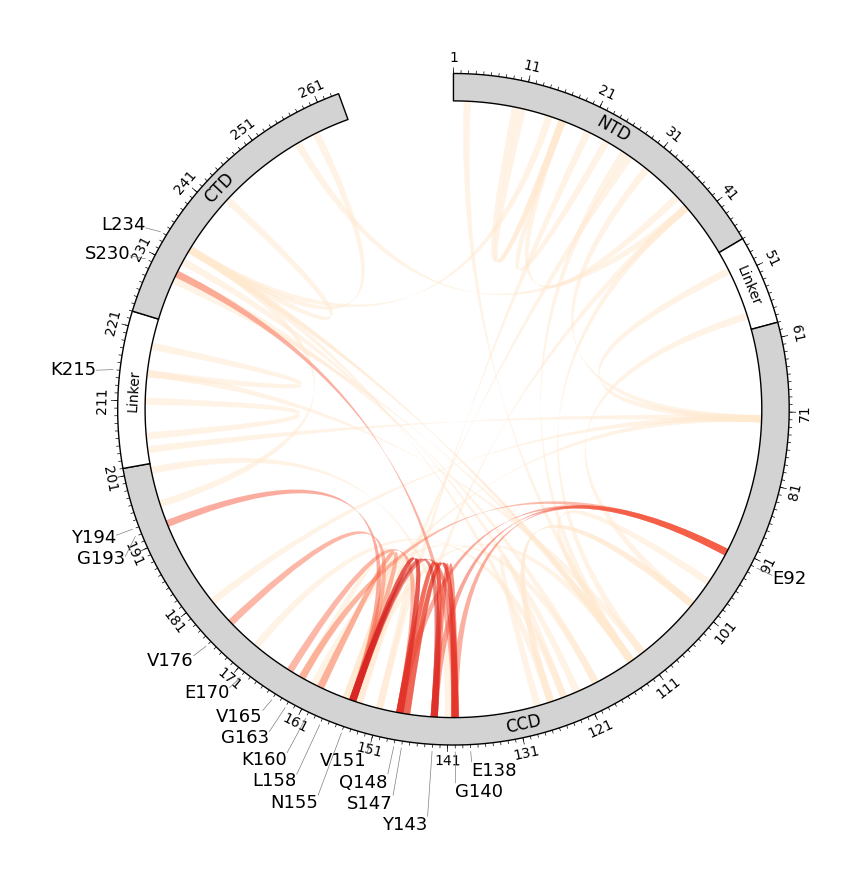

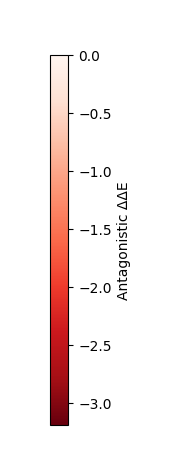

In [383]:
IN_circos_antag,sector =circ.initialize_IN_circos_w_ticks(actual_length, (90, 98))
circ.add_DRM_annotation(IN_circos_antag,sector, (100, 100),combined_DRM)
circ.connect_background_ant_cords(IN_circos_antag,sector,IN_kn_path, 50,1,0.5)
circ.connect_ant_cords(IN_circos_antag,sector,IN_kn_path, bottom_20_DRM,IN_redux_dict,1,0.5)
fig = IN_circos_antag.plotfig()
plt.show()

sm = circ.plot_colorbar(-3.18745, 0, False)
cbar = plt.colorbar(sm, ax=plt.gca(), orientation='vertical', label='Antagonistic ΔΔE')
plt.gca().remove()